# **Numerical Quantum CLUE (with Python)**

Let us investigate what happen when we increase the epsilon for the numerical CLUE in an example of a quantum circuit.

In [1]:
import sys
sys.path.append("../papers/quantum") # python files for quantum tests are here

from q_sat import SATFormula
from q_maxcut import UndirectedGraph
from q_benchmark import QuantumBenchmark
from q_numerical import *
from shutil import get_terminal_size

import logging
logger = logging.getLogger("clue")
logger.setLevel(logging.ERROR)

threshold=1e-3

## **Specific examples**

### **Trivial Graph example** (7 nodes)

In [3]:
G = UndirectedGraph.generate_example(_, 7)
A = analysis(G)
print("Graph: ", G)
A

2024-07-26 05:02:41 WARNING  [lumping] lumped size (128) and original size (128) are the same.


2024-07-26 05:02:45 WARNING  [lumping] lumped size (128) and original size (128) are the same.


2024-07-26 05:02:50 WARNING  [lumping] lumped size (128) and original size (128) are the same.


2024-07-26 05:02:54 WARNING  [lumping] lumped size (128) and original size (128) are the same.


2024-07-26 05:02:57 WARNING  [lumping] lumped size (128) and original size (128) are the same.


2024-07-26 05:03:01 WARNING  [lumping] lumped size (128) and original size (128) are the same.


[analysis] Broken analysis. We keep working but we do not cache the result      


KeyboardInterrupt: 

In [18]:
epsilon_intervals(A)

{128: (0.0, 1e-10),
 9: (1e-10, 0.17392559070783808),
 8: (0.17392559070783808, 0.19435730883279212),
 1: (0.19435730883279212, 0.19435730990935285)}

[analysis] COMPLETED (with 0 lumpings) (from CACHE)                             
[analysis] COMPLETED (with 0 lumpings) (from CACHE)                             
[direct @ 9] COMPLETED                                                          
[analysis] COMPLETED (with 0 lumpings) (from CACHE)                             
[direct @ 8] COMPLETED                                                          
[analysis] COMPLETED (with 0 lumpings) (from CACHE)                             
[direct @ 1] COMPLETED                                                          


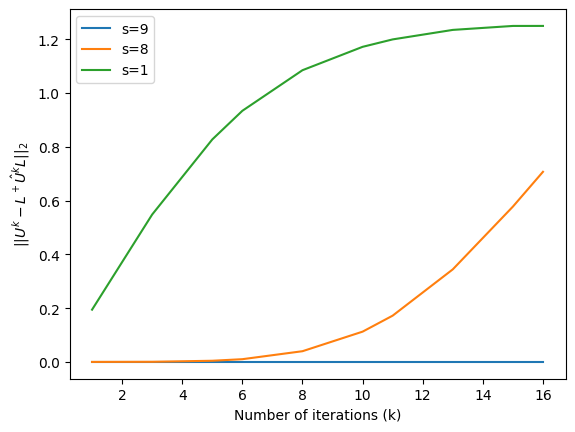

[graph] COMPLETED                                                               


In [19]:
generate_error_graph(G)

[analysis] COMPLETED (with 0 lumpings) (from CACHE)                             
[analysis] COMPLETED (with 0 lumpings) (from CACHE)                             
[unitary @ 9] COMPLETED                                                         
[analysis] COMPLETED (with 0 lumpings) (from CACHE)                             
[unitary @ 8] COMPLETED                                                         
[analysis] COMPLETED (with 0 lumpings) (from CACHE)                             
[unitary @ 1] COMPLETED                                                         


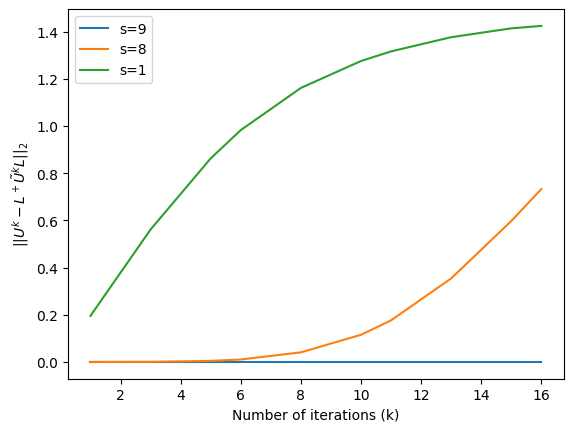

[graph] COMPLETED                                                               


In [20]:
generate_error_graph(G, closest_unitary_error, r"\tilde{U}")

### **Quantum Walk example** (7 nodes) (<font color='green'>Nice</font>)

In [2]:
QW = QuantumBenchmark.generate_example("qwalk", 7, 0)
A = analysis(QW, threshold)
print("Circuit: ", QW)
A

[analysis] COMPLETED: Saved in file (83.6506 s., 66 lumpings, 9 dist. lumpings) 
Circuit:  qwalk with 7 qubits.


{1: (0.9999999999999999,
  Lumped system [128 -> 1] (None) [LDESystem -- 1 -- SparsePolynomial]),
 2: (0.9838947753906249,
  Lumped system [128 -> 2] (None) [LDESystem -- 2 -- SparsePolynomial]),
 30: (0.9614450683593749,
  Lumped system [128 -> 30] (None) [LDESystem -- 30 -- SparsePolynomial]),
 32: (0.827722900390625,
  Lumped system [128 -> 32] (None) [LDESystem -- 32 -- SparsePolynomial]),
 36: (0.633484130859375,
  Lumped system [128 -> 36] (None) [LDESystem -- 36 -- SparsePolynomial]),
 40: (0.502690185546875,
  Lumped system [128 -> 40] (None) [LDESystem -- 40 -- SparsePolynomial]),
 48: (0.4333889160156249,
  Lumped system [128 -> 48] (None) [LDESystem -- 48 -- SparsePolynomial]),
 60: (0.3562790527343749,
  Lumped system [128 -> 60] (None) [LDESystem -- 60 -- SparsePolynomial]),
 64: (0.142518798828125,
  Lumped system [128 -> 64] (None) [LDESystem -- 64 -- SparsePolynomial])}

In [3]:
for (s, I) in epsilon_intervals(A, threshold).items():
    print(s, "->", I)

64 -> (0.0, 0.28503759765625)
60 -> (0.28503759765625, 0.4275205078124998)
48 -> (0.4275205078124998, 0.43925732421875)
40 -> (0.43925732421875, 0.5661230468749998)
36 -> (0.5661230468749998, 0.7008452148437503)
32 -> (0.7008452148437503, 0.9546005859374997)
30 -> (0.9546005859374997, 0.9682895507812501)
2 -> (0.9682895507812501, 0.9994999999999996)
1 -> (0.9994999999999996, 1.0005000000000002)


[backward @ 1] COMPLETED (2.4655 sec, 13 iters.)                                
[backward @ 2] COMPLETED (1.2289 sec, 14 iters.)                                
[backward @ 30] COMPLETED (8.9194 sec, 45 iters.)                               
[backward @ 32] COMPLETED (5.0323 sec, 48 iters.)                               
[backward @ 36] COMPLETED (5.9398 sec, 54 iters.)                               
[backward @ 40] COMPLETED (6.5145 sec, 60 iters.)                               
[backward @ 48] COMPLETED (8.4517 sec, 72 iters.)                               
[backward @ 60] COMPLETED (10.3099 sec, 90 iters.)                              
[backward @ 64] COMPLETED (10.3219 sec, 96 iters.)                              


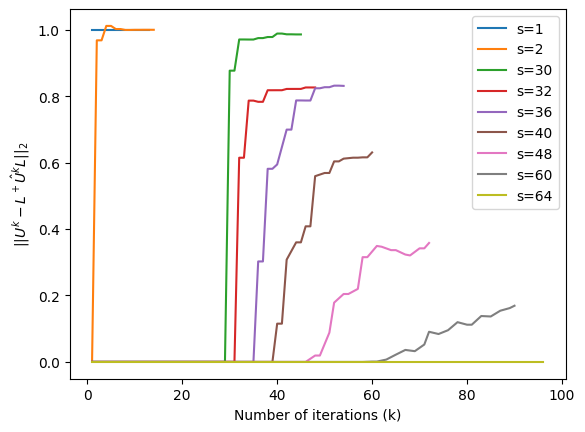

[graph] COMPLETED                                                               


In [4]:
generate_error_graph(QW, threshold=threshold)

$||\hat{U}L\ket{x} - LU\ket{x}||$

[forward @ 1 COMPLETED (0.0478 sec)                                             
[forward @ 2 COMPLETED (0.0726 sec)                                             
[forward @ 30 COMPLETED (0.6516 sec)                                            
[forward @ 32 COMPLETED (0.7041 sec)                                            
[forward @ 36 COMPLETED (0.7969 sec)                                            
[forward @ 40 COMPLETED (0.8918 sec)                                            
[forward @ 48 COMPLETED (1.0549 sec)                                            
[forward @ 60 COMPLETED (1.2948 sec)                                            
[forward @ 64 COMPLETED (1.4564 sec)                                            


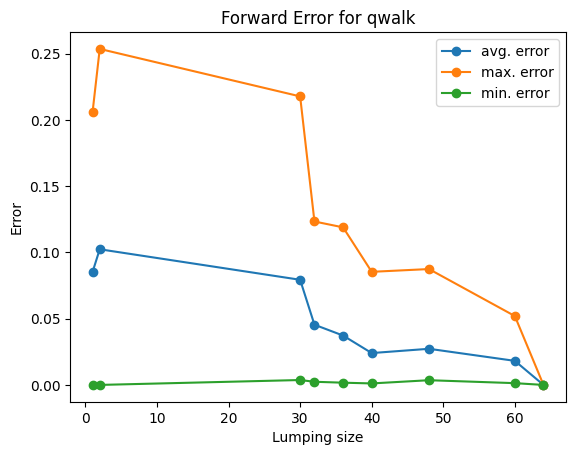

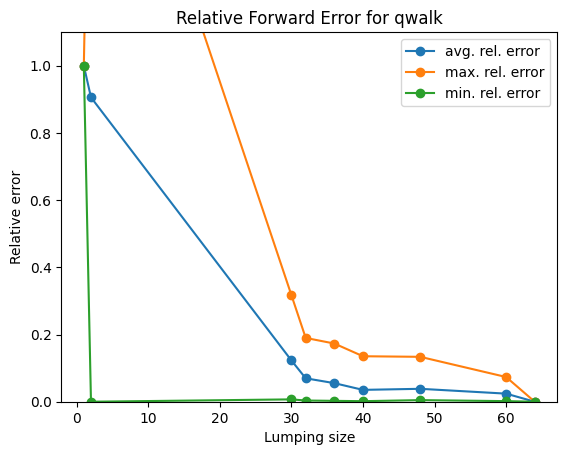

In [5]:
generate_error_graph(QW, method=forward_error, threshold=threshold)

### **Amplitude Estimation** (7 nodes) (<font color='purple'>Not working</font>)

In [6]:
AE = QuantumBenchmark.generate_example("ae", 7, 0)
A = analysis(AE, threshold)
print("Circuit: ", AE)
A

[analysis] COMPLETED: Saved in file (1019.6373 s., 66 lumpings, 10 dist. lumpings)
Circuit:  ae with 7 qubits.


{1: (0.9999827056537817,
  Lumped system [128 -> 1] (None) [LDESystem -- 1 -- SparsePolynomial]),
 2: (0.9936383330104714,
  Lumped system [128 -> 2] (None) [LDESystem -- 2 -- SparsePolynomial]),
 13: (0.9804615590589812,
  Lumped system [128 -> 13] (None) [LDESystem -- 13 -- SparsePolynomial]),
 15: (0.9721650717561912,
  Lumped system [128 -> 15] (None) [LDESystem -- 15 -- SparsePolynomial]),
 45: (0.92433826259893,
  Lumped system [128 -> 45] (None) [LDESystem -- 45 -- SparsePolynomial]),
 98: (0.8091634976896076,
  Lumped system [128 -> 98] (None) [LDESystem -- 98 -- SparsePolynomial]),
 114: (0.690084503461325,
  Lumped system [128 -> 114] (None) [LDESystem -- 114 -- SparsePolynomial]),
 119: (0.4416779130424896,
  Lumped system [128 -> 119] (None) [LDESystem -- 119 -- SparsePolynomial]),
 125: (0.20156780992644435,
  Lumped system [128 -> 125] (None) [LDESystem -- 125 -- SparsePolynomial]),
 128: (0.0795606437089417,
  Lumped system [128 -> 128] (None) [LDESystem -- 128 -- Sparse

In [7]:
for (s, I) in epsilon_intervals(A, threshold).items():
    print(s, "->", I)

128 -> (0.0, 0.1591212874178834)
125 -> (0.1591212874178834, 0.2440143324350053)
119 -> (0.2440143324350053, 0.639341493649974)
114 -> (0.639341493649974, 0.740827513272676)
98 -> (0.740827513272676, 0.8774994821065392)
45 -> (0.8774994821065392, 0.9711770430913209)
15 -> (0.9711770430913209, 0.9731531004210614)
13 -> (0.9731531004210614, 0.9877700176969011)
2 -> (0.9877700176969011, 0.9995066483240418)
1 -> (0.9995066483240418, 1.0004587629835215)


[backward @ 1] COMPLETED (7.9198 sec, 13 iters.)                                
[backward @ 2] COMPLETED (4.2132 sec, 14 iters.)                                
[backward @ 13] COMPLETED (11.3481 sec, 25 iters.)                              
[backward @ 15] COMPLETED (7.4371 sec, 27 iters.)                               
[backward @ 45] COMPLETED (30.9794 sec, 68 iters.)                              
[backward @ 98] COMPLETED (75.0141 sec, 147 iters.)                             
[backward @ 114] COMPLETED (91.2670 sec, 171 iters.)                            
[backward @ 119] COMPLETED (92.4950 sec, 179 iters.)                            
[backward @ 125] COMPLETED (104.4907 sec, 188 iters.)                           


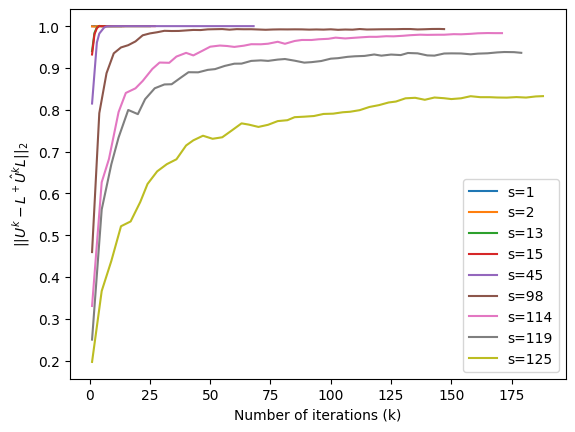

[graph] COMPLETED                                                               


In [8]:
generate_error_graph(AE, threshold=threshold)

In [10]:
L, L_plus, U, Uhat = matrices_example(AE, 74, threshold)

In [43]:
al = lumping_from_analysis(A, 74)

In [27]:
L.row(1).inner_product(L.row(2))

(-0.005319247364052243+0.0028086701243695946j)

In [28]:
v0 = L.row(0)

In [29]:
v1 = U*v0
v1 = v1 - v0*v1.inner_product(v0)
v1.scale(1/v1.norm())

In [40]:
v2 = U*v1
v2 = v2 - v0*v0.inner_product(v2) - v1*v1.inner_product(v2)
v2.scale(1/v2.norm())

In [41]:
(L.row(2) - v2).norm()

1.412570955233497

In [ ]:
generate_error_graph(GS, threshold=threshold)

[analysis] COMPLETED (with 0 lumpings) (from CACHE)                             
[analysis] COMPLETED (with 0 lumpings) (from CACHE)                             
[unitary @ 1] COMPLETED                                                         
[analysis] COMPLETED (with 0 lumpings) (from CACHE)                             
[unitary @ 4] COMPLETED                                                         
[analysis] COMPLETED (with 0 lumpings) (from CACHE)                             
[unitary @ 14] COMPLETED                                                        
[analysis] COMPLETED (with 0 lumpings) (from CACHE)                             
[unitary @ 7] COMPLETED                                                         


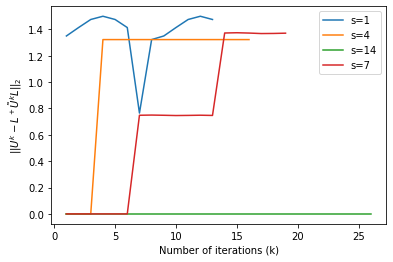

[graph] COMPLETED                                                               


In [12]:
generate_error_graph(GS, closest_unitary_error, r"\tilde{U}", threshold=threshold)

### **Amplitude Estimation** (7 nodes) (<font color='purple'>Not working</font>)

In [6]:
AE = QuantumBenchmark.generate_example("ae", 7, 0)
A = analysis(AE, threshold)
print("Circuit: ", AE)
A

[analysis] COMPLETED: Saved in file (133.9547 s., 64 lumpings, 11 dist. lumpings)
Circuit:  ae with 7 qubits.


{1: (0.9999827056537817,
  Lumped system [128 -> 1] (None) [LDESystem -- 1 -- SparsePolynomial]),
 2: (0.9882700176969015,
  Lumped system [128 -> 2] (None) [LDESystem -- 2 -- SparsePolynomial]),
 7: (0.9755812724102811,
  Lumped system [128 -> 7] (None) [LDESystem -- 7 -- SparsePolynomial]),
 8: (0.9614284411290509,
  Lumped system [128 -> 8] (None) [LDESystem -- 8 -- SparsePolynomial]),
 11: (0.9321467212368502,
  Lumped system [128 -> 11] (None) [LDESystem -- 11 -- SparsePolynomial]),
 17: (0.9082333166582197,
  Lumped system [128 -> 17] (None) [LDESystem -- 17 -- SparsePolynomial]),
 21: (0.8989607720256896,
  Lumped system [128 -> 21] (None) [LDESystem -- 21 -- SparsePolynomial]),
 28: (0.8935924567121194,
  Lumped system [128 -> 28] (None) [LDESystem -- 28 -- SparsePolynomial]),
 33: (0.8823677974201091,
  Lumped system [128 -> 33] (None) [LDESystem -- 33 -- SparsePolynomial]),
 74: (0.8652867941496587,
  Lumped system [128 -> 74] (None) [LDESystem -- 74 -- SparsePolynomial]),
 1

In [7]:
for (s, I) in epsilon_intervals(A, threshold).items():
    print(s, "->", I)

128 -> (0.0, 0.8560262208522584)
74 -> (0.8560262208522584, 0.874547367447059)
33 -> (0.874547367447059, 0.8901882273931592)
28 -> (0.8901882273931592, 0.8969966860310796)
21 -> (0.8969966860310796, 0.9009248580202995)
17 -> (0.9009248580202995, 0.9155417752961399)
11 -> (0.9155417752961399, 0.9487516671775604)
8 -> (0.9487516671775604, 0.9741052150805414)
7 -> (0.9741052150805414, 0.9770573297400209)
2 -> (0.9770573297400209, 0.999482705653782)
1 -> (0.999482705653782, 1.0004827056537813)


[backward @ 1] COMPLETED (3.5947 sec, 13 iters.)                                
[backward @ 2] COMPLETED (2.0501 sec, 14 iters.)                                
[backward @ 7] COMPLETED (3.4279 sec, 19 iters.)                                
[backward @ 8] COMPLETED (2.7117 sec, 20 iters.)                                
[backward @ 11] COMPLETED (3.3916 sec, 23 iters.)                               
[backward @ 17] COMPLETED (4.6014 sec, 29 iters.)                               
[backward @ 21] COMPLETED (4.8892 sec, 33 iters.)                               
[backward @ 28] COMPLETED (6.6906 sec, 42 iters.)                               
[backward @ 33] COMPLETED (7.6134 sec, 50 iters.)                               
[backward @ 74] COMPLETED (23.2492 sec, 111 iters.)                             


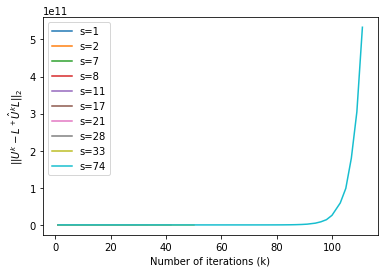

[graph] COMPLETED                                                               


In [8]:
generate_error_graph(AE, threshold=threshold)

[forward @ 1 COMPLETED (0.0379 sec)                                             
[forward @ 2 COMPLETED (0.0377 sec)                                             
[forward @ 7 COMPLETED (0.0720 sec)                                             
[forward @ 8 COMPLETED (0.0831 sec)                                             
[forward @ 11 COMPLETED (0.1070 sec)                                            
[forward @ 17 COMPLETED (0.1380 sec)                                            
[forward @ 21 COMPLETED (0.1647 sec)                                            
[forward @ 28 COMPLETED (0.2258 sec)                                            
[forward @ 33 COMPLETED (0.2662 sec)                                            
[forward @ 74 COMPLETED (0.6267 sec)                                            


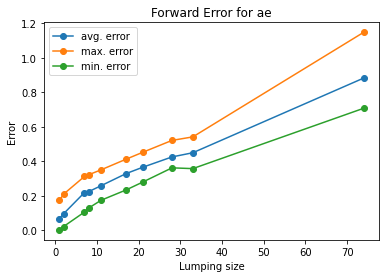

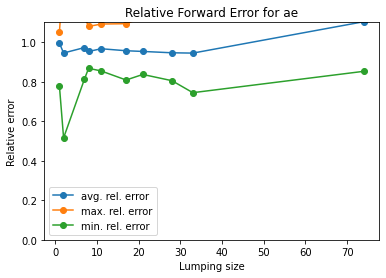

In [9]:
generate_error_graph(AE, method=forward_error, threshold=threshold)

### **Portfolio QAOA** (7 nodes) (<font color='red'>Bad reductions</font>)

In [10]:
PQAOA = QuantumBenchmark.generate_example("portfolioqaoa", 7, 0)
A = analysis(PQAOA, threshold)
print("Circuit: ", PQAOA)
A

[analysis] COMPLETED: Saved in file (31.1135 s., 38 lumpings, 5 dist. lumpings) 
Circuit:  portfolioqaoa with 7 qubits.


{2: (0.9624918565127198,
  Lumped system [128 -> 2] (None) [LDESystem -- 2 -- SparsePolynomial]),
 3: (0.8812310370703202,
  Lumped system [128 -> 3] (None) [LDESystem -- 3 -- SparsePolynomial]),
 4: (0.8150545613567491,
  Lumped system [128 -> 4] (None) [LDESystem -- 4 -- SparsePolynomial]),
 6: (0.741579209645358,
  Lumped system [128 -> 6] (None) [LDESystem -- 6 -- SparsePolynomial]),
 128: (0.34403376363074367,
  Lumped system [128 -> 128] (None) [LDESystem -- 128 -- SparsePolynomial])}

In [11]:
for (s, I) in epsilon_intervals(A, threshold).items():
    print(s, "->", I)

128 -> (0.0, 0.6880675272614873)
6 -> (0.6880675272614873, 0.7950908920292286)
4 -> (0.7950908920292286, 0.8350182306842697)
3 -> (0.8350182306842697, 0.9274438434563708)
2 -> (0.9274438434563708, 0.9975398695690689)


[backward @ 2] COMPLETED (4.9767 sec, 14 iters.)                                
[backward @ 3] COMPLETED (2.5307 sec, 15 iters.)                                
[backward @ 4] COMPLETED (2.3253 sec, 16 iters.)                                
[backward @ 6] COMPLETED (2.6819 sec, 18 iters.)                                


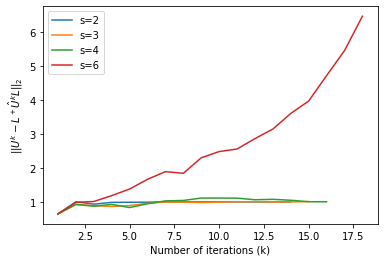

[graph] COMPLETED                                                               


In [12]:
generate_error_graph(PQAOA, threshold=threshold)

[forward @ 2 COMPLETED (0.0785 sec)                                             
[forward @ 3 COMPLETED (0.0346 sec)                                             
[forward @ 4 COMPLETED (0.0401 sec)                                             
[forward @ 6 COMPLETED (0.0517 sec)                                             


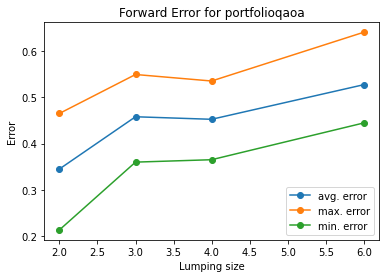

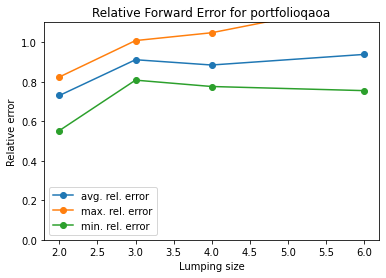

In [13]:
generate_error_graph(PQAOA, method=forward_error, threshold=threshold)

### **Portfolio VQE** (7 nodes) (<font color='blue'>Bad backward, good forward</font>)

In [14]:
PVQE = QuantumBenchmark.generate_example("portfoliovqe", 7, 0)
A = analysis(PVQE, threshold)
print("Circuit: ", PVQE)
A

[analysis] COMPLETED: Saved in file (628.1871 s., 83 lumpings, 13 dist. lumpings)
Circuit:  portfoliovqe with 7 qubits.


{1: (0.9975848711073058,
  Lumped system [128 -> 1] (None) [LDESystem -- 1 -- SparsePolynomial]),
 2: (0.9961242975656446,
  Lumped system [128 -> 2] (None) [LDESystem -- 2 -- SparsePolynomial]),
 6: (0.9834659935379151,
  Lumped system [128 -> 6] (None) [LDESystem -- 6 -- SparsePolynomial]),
 12: (0.9693471159685245,
  Lumped system [128 -> 12] (None) [LDESystem -- 12 -- SparsePolynomial]),
 54: (0.9596099590241173,
  Lumped system [128 -> 54] (None) [LDESystem -- 54 -- SparsePolynomial]),
 70: (0.9479253706908286,
  Lumped system [128 -> 70] (None) [LDESystem -- 70 -- SparsePolynomial]),
 88: (0.9342933509686584,
  Lumped system [128 -> 88] (None) [LDESystem -- 88 -- SparsePolynomial]),
 98: (0.9080030272187587,
  Lumped system [128 -> 98] (None) [LDESystem -- 98 -- SparsePolynomial]),
 100: (0.8018680165247194,
  Lumped system [128 -> 100] (None) [LDESystem -- 100 -- SparsePolynomial]),
 114: (0.6811272704140692,
  Lumped system [128 -> 114] (None) [LDESystem -- 114 -- SparsePolynom

In [15]:
for (s, I) in epsilon_intervals(A, threshold).items():
    print(s, "->", I)

128 -> (0.0, 0.006842294166644371)
126 -> (0.006842294166644371, 0.39435485624849487)
116 -> (0.39435485624849487, 0.6494946524975254)
114 -> (0.6494946524975254, 0.712759888330613)
100 -> (0.712759888330613, 0.8909761447188258)
98 -> (0.8909761447188258, 0.9250299097186916)
88 -> (0.9250299097186916, 0.9435567922186252)
70 -> (0.9435567922186252, 0.952293949163032)
54 -> (0.952293949163032, 0.9669259688852025)
12 -> (0.9669259688852025, 0.9717682630518465)
6 -> (0.9717682630518465, 0.9951637240239837)
2 -> (0.9951637240239837, 0.9970848711073055)
1 -> (0.9970848711073055, 0.998084871107306)


[backward @ 1] COMPLETED (3.6137 sec, 13 iters.)                                
[backward @ 2] COMPLETED (2.0675 sec, 14 iters.)                                
[backward @ 6] COMPLETED (3.0670 sec, 18 iters.)                                
[backward @ 12] COMPLETED (3.9966 sec, 24 iters.)                               
[backward @ 54] COMPLETED (17.3837 sec, 81 iters.)                              
[backward @ 70] COMPLETED (16.1958 sec, 105 iters.)                             
[backward @ 88] COMPLETED (23.7510 sec, 132 iters.)                             
[backward @ 98] COMPLETED (27.9413 sec, 147 iters.)                             
[backward @ 100] COMPLETED (27.3505 sec, 150 iters.)                            
[backward @ 114] COMPLETED (34.9517 sec, 171 iters.)                            
[backward @ 116] COMPLETED (35.8765 sec, 174 iters.)                            
[backward @ 126] COMPLETED (46.2362 sec, 189 iters.)                            


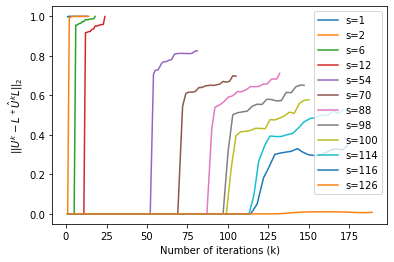

[graph] COMPLETED                                                               


In [16]:
generate_error_graph(PVQE, threshold=threshold)

[forward @ 1 COMPLETED (0.0303 sec)                                             
[forward @ 2 COMPLETED (0.0338 sec)                                             
[forward @ 6 COMPLETED (0.0500 sec)                                             
[forward @ 12 COMPLETED (0.0734 sec)                                            
[forward @ 54 COMPLETED (0.3196 sec)                                            
[forward @ 70 COMPLETED (0.4319 sec)                                            
[forward @ 88 COMPLETED (0.5703 sec)                                            
[forward @ 98 COMPLETED (0.6573 sec)                                            
[forward @ 100 COMPLETED (0.6832 sec)                                           
[forward @ 114 COMPLETED (0.8096 sec)                                           
[forward @ 116 COMPLETED (0.8322 sec)                                           
[forward @ 126 COMPLETED (0.9085 sec)                                           


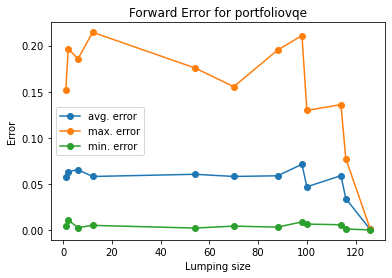

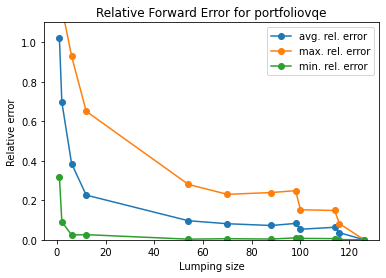

In [17]:
generate_error_graph(PVQE, method=forward_error, threshold=threshold)

### **QPE Exact** (7 nodes) (<font color='purple'>Not working</font>)

In [18]:
QPEE = QuantumBenchmark.generate_example("qpeexact", 7, 0)
A = analysis(QPEE, threshold)
print("Circuit: ", QPEE)
A

[analysis] COMPLETED: Saved in file (27.5011 s., 49 lumpings, 8 dist. lumpings) 
Circuit:  qpeexact with 7 qubits.


{1: (0.9999999999999999,
  Lumped system [128 -> 1] (None) [LDESystem -- 1 -- SparsePolynomial]),
 4: (0.9843828124999998,
  Lumped system [128 -> 4] (None) [LDESystem -- 4 -- SparsePolynomial]),
 10: (0.943875732421875,
  Lumped system [128 -> 10] (None) [LDESystem -- 10 -- SparsePolynomial]),
 21: (0.915569580078125,
  Lumped system [128 -> 21] (None) [LDESystem -- 21 -- SparsePolynomial]),
 32: (0.906784912109375,
  Lumped system [128 -> 32] (None) [LDESystem -- 32 -- SparsePolynomial]),
 36: (0.88287109375,
  Lumped system [128 -> 36] (None) [LDESystem -- 36 -- SparsePolynomial]),
 56: (0.8604213867187499,
  Lumped system [128 -> 56] (None) [LDESystem -- 56 -- SparsePolynomial]),
 128: (0.4280205078124999,
  Lumped system [128 -> 128] (None) [LDESystem -- 128 -- SparsePolynomial])}

In [19]:
for (s, I) in epsilon_intervals(A, threshold).items():
    print(s, "->", I)

128 -> (0.0, 0.8560410156249998)
56 -> (0.8560410156249998, 0.8648017578125)
36 -> (0.8648017578125, 0.9009404296874999)
32 -> (0.9009404296874999, 0.91262939453125)
21 -> (0.91262939453125, 0.9185097656249999)
10 -> (0.9185097656249999, 0.96924169921875)
4 -> (0.96924169921875, 0.9995239257812496)
1 -> (0.9995239257812496, 1.0004760742187502)


[backward @ 1] COMPLETED (1.2791 sec, 13 iters.)                                
[backward @ 4] COMPLETED (1.3653 sec, 16 iters.)                                
[backward @ 10] COMPLETED (1.7203 sec, 22 iters.)                               
[backward @ 21] COMPLETED (2.3644 sec, 33 iters.)                               
[backward @ 32] COMPLETED (2.9903 sec, 48 iters.)                               
[backward @ 36] COMPLETED (2.6484 sec, 54 iters.)                               
[backward @ 56] COMPLETED (4.5622 sec, 84 iters.)                               


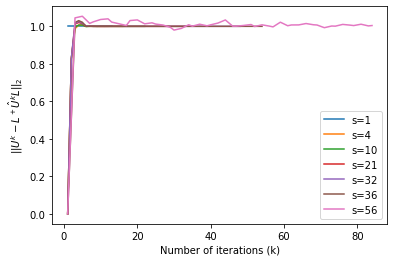

[graph] COMPLETED                                                               


In [20]:
generate_error_graph(QPEE, threshold=threshold)

[forward @ 1 COMPLETED (0.0968 sec)                                             
[forward @ 4 COMPLETED (0.0278 sec)                                             
[forward @ 10 COMPLETED (0.0368 sec)                                            
[forward @ 21 COMPLETED (0.0618 sec)                                            
[forward @ 32 COMPLETED (0.0832 sec)                                            
[forward @ 36 COMPLETED (0.0930 sec)                                            
[forward @ 56 COMPLETED (0.1421 sec)                                            


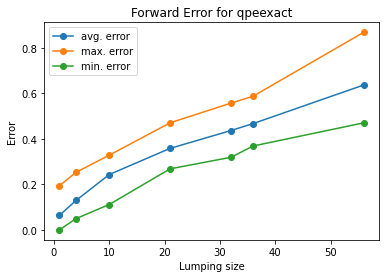

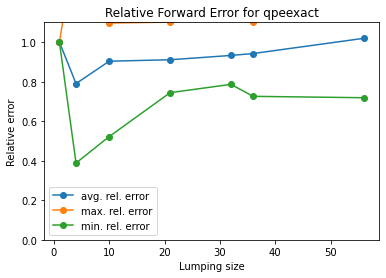

In [21]:
generate_error_graph(QPEE, method=forward_error, threshold=threshold)

### **QPE Inexact** (7 nodes) <font color='purple'>Not working</font>

In [22]:
QPEI = QuantumBenchmark.generate_example("qpeinexact", 7, 0)
A = analysis(QPEI, threshold)
print("Circuit: ", QPEI)
A

[analysis] COMPLETED: Saved in file (51.3340 s., 71 lumpings, 11 dist. lumpings)
Circuit:  qpeinexact with 7 qubits.


{2: (0.9999999999999998,
  Lumped system [128 -> 2] (None) [LDESystem -- 2 -- SparsePolynomial]),
 4: (0.9936555175781248,
  Lumped system [128 -> 4] (None) [LDESystem -- 4 -- SparsePolynomial]),
 7: (0.9858469238281249,
  Lumped system [128 -> 7] (None) [LDESystem -- 7 -- SparsePolynomial]),
 9: (0.9687656249999999,
  Lumped system [128 -> 9] (None) [LDESystem -- 9 -- SparsePolynomial]),
 11: (0.9472919921874998,
  Lumped system [128 -> 11] (None) [LDESystem -- 11 -- SparsePolynomial]),
 14: (0.9253303222656248,
  Lumped system [128 -> 14] (None) [LDESystem -- 14 -- SparsePolynomial]),
 23: (0.9062968749999998,
  Lumped system [128 -> 23] (None) [LDESystem -- 23 -- SparsePolynomial]),
 32: (0.8643256835937497,
  Lumped system [128 -> 32] (None) [LDESystem -- 32 -- SparsePolynomial]),
 44: (0.8121057128906248,
  Lumped system [128 -> 44] (None) [LDESystem -- 44 -- SparsePolynomial]),
 78: (0.7706225585937498,
  Lumped system [128 -> 78] (None) [LDESystem -- 78 -- SparsePolynomial]),
 1

In [23]:
for (s, I) in epsilon_intervals(A, threshold).items():
    print(s, "->", I)

128 -> (0.0, 0.7428164062499998)
78 -> (0.7428164062499998, 0.7984287109374999)
44 -> (0.7984287109374999, 0.8257827148437498)
32 -> (0.8257827148437498, 0.9028686523437497)
23 -> (0.9028686523437497, 0.9097250976562499)
14 -> (0.9097250976562499, 0.9409355468749998)
11 -> (0.9409355468749998, 0.9536484374999998)
9 -> (0.9536484374999998, 0.9838828124999999)
7 -> (0.9838828124999999, 0.9878110351562499)
4 -> (0.9878110351562499, 0.9994999999999996)
2 -> (0.9994999999999996, 1.0005)


[backward @ 2] COMPLETED (1.8625 sec, 14 iters.)                                
[backward @ 4] COMPLETED (1.6714 sec, 16 iters.)                                
[backward @ 7] COMPLETED (1.8566 sec, 19 iters.)                                
[backward @ 9] COMPLETED (1.8597 sec, 21 iters.)                                
[backward @ 11] COMPLETED (1.9669 sec, 23 iters.)                               
[backward @ 14] COMPLETED (2.1218 sec, 26 iters.)                               
[backward @ 23] COMPLETED (2.9341 sec, 35 iters.)                               
[backward @ 32] COMPLETED (3.6749 sec, 48 iters.)                               
[backward @ 44] COMPLETED (4.6538 sec, 66 iters.)                               
[backward @ 78] COMPLETED (8.7466 sec, 117 iters.)                              


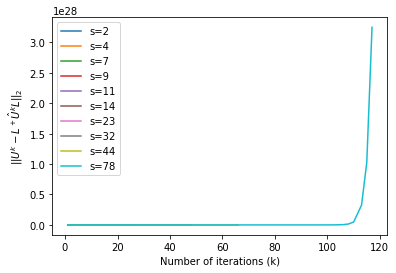

[graph] COMPLETED                                                               


In [24]:
generate_error_graph(QPEI, threshold=threshold)

[forward @ 2 COMPLETED (0.0391 sec)                                             
[forward @ 4 COMPLETED (0.0353 sec)                                             
[forward @ 7 COMPLETED (0.0381 sec)                                             
[forward @ 9 COMPLETED (0.0484 sec)                                             
[forward @ 11 COMPLETED (0.0545 sec)                                            
[forward @ 14 COMPLETED (0.0606 sec)                                            
[forward @ 23 COMPLETED (0.0872 sec)                                            
[forward @ 32 COMPLETED (0.1113 sec)                                            
[forward @ 44 COMPLETED (0.1492 sec)                                            
[forward @ 78 COMPLETED (0.2589 sec)                                            


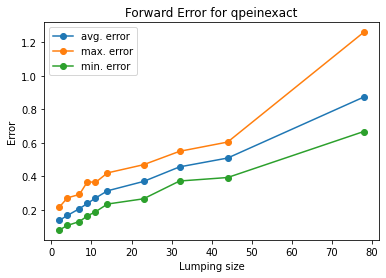

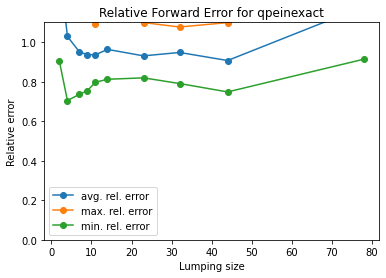

In [25]:
generate_error_graph(QPEI, method=forward_error, threshold=threshold)

### **Quantum Neural Network** (7 nodes) (<font color='purple'>Not working</font>)

In [26]:
QNN = QuantumBenchmark.generate_example("qnn", 7, 0)
A = analysis(QNN, threshold)
print("Circuit: ", QNN)
A

[analysis] COMPLETED: Saved in file (69.5337 s., 47 lumpings, 8 dist. lumpings) 
Circuit:  qnn with 7 qubits.


{1: (0.9889741651889766,
  Lumped system [128 -> 1] (None) [LDESystem -- 1 -- SparsePolynomial]),
 4: (0.981734364174409,
  Lumped system [128 -> 4] (None) [LDESystem -- 4 -- SparsePolynomial]),
 7: (0.9667721087443023,
  Lumped system [128 -> 7] (None) [LDESystem -- 7 -- SparsePolynomial]),
 9: (0.9566363873239075,
  Lumped system [128 -> 9] (None) [LDESystem -- 9 -- SparsePolynomial]),
 13: (0.9465006659035128,
  Lumped system [128 -> 13] (None) [LDESystem -- 13 -- SparsePolynomial]),
 17: (0.9204373822510691,
  Lumped system [128 -> 17] (None) [LDESystem -- 17 -- SparsePolynomial]),
 23: (0.8909955247918271,
  Lumped system [128 -> 23] (None) [LDESystem -- 23 -- SparsePolynomial]),
 128: (0.4397145948837738,
  Lumped system [128 -> 128] (None) [LDESystem -- 128 -- SparsePolynomial])}

In [27]:
for (s, I) in epsilon_intervals(A, threshold).items():
    print(s, "->", I)

128 -> (0.0, 0.8794291897675476)
23 -> (0.8794291897675476, 0.9025618598161066)
17 -> (0.9025618598161066, 0.9383129046860316)
13 -> (0.9383129046860316, 0.954688427120994)
9 -> (0.954688427120994, 0.9585843475268211)
7 -> (0.9585843475268211, 0.9749598699617835)
4 -> (0.9749598699617835, 0.9885088583870344)
1 -> (0.9885088583870344, 0.9894394719909189)


[backward @ 1] COMPLETED (3.6589 sec, 13 iters.)                                
[backward @ 4] COMPLETED (3.1199 sec, 16 iters.)                                
[backward @ 7] COMPLETED (3.2789 sec, 19 iters.)                                
[backward @ 9] COMPLETED (3.1976 sec, 21 iters.)                                
[backward @ 13] COMPLETED (4.3615 sec, 25 iters.)                               
[backward @ 17] COMPLETED (4.4968 sec, 29 iters.)                               
[backward @ 23] COMPLETED (5.7621 sec, 35 iters.)                               


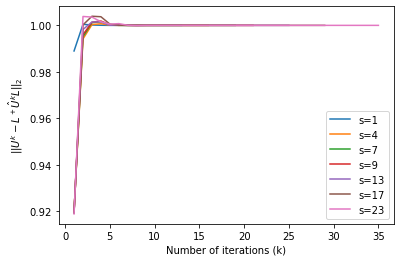

[graph] COMPLETED                                                               


In [28]:
generate_error_graph(QNN, threshold=threshold)

[forward @ 1 COMPLETED (0.0882 sec)                                             
[forward @ 4 COMPLETED (0.0358 sec)                                             
[forward @ 7 COMPLETED (0.0504 sec)                                             
[forward @ 9 COMPLETED (0.0618 sec)                                             
[forward @ 13 COMPLETED (0.0848 sec)                                            
[forward @ 17 COMPLETED (0.0991 sec)                                            
[forward @ 23 COMPLETED (0.1339 sec)                                            


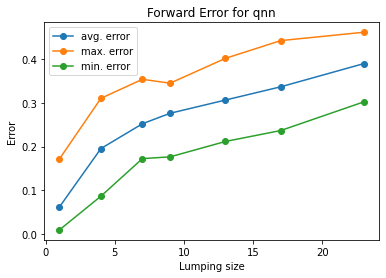

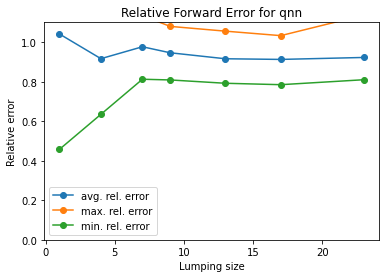

In [29]:
generate_error_graph(QNN, method=forward_error, threshold=threshold)

### **W-State** (7 nodes) (<font color='green'>Nice</font>)

In [30]:
WS = QuantumBenchmark.generate_example("wstate", 7, 0)
A = analysis(WS, threshold)
print("Circuit: ", WS)
A

[analysis] COMPLETED: Saved in file (346.6418 s., 73 lumpings, 11 dist. lumpings)
Circuit:  wstate with 7 qubits.


{1: (1.0,
  Lumped system [128 -> 1] (None) [LDESystem -- 1 -- SparsePolynomial]),
 2: (0.9629091796875,
  Lumped system [128 -> 2] (None) [LDESystem -- 2 -- SparsePolynomial]),
 3: (0.919473876953125,
  Lumped system [128 -> 3] (None) [LDESystem -- 3 -- SparsePolynomial]),
 4: (0.9116652832031251,
  Lumped system [128 -> 4] (None) [LDESystem -- 4 -- SparsePolynomial]),
 13: (0.9033686523437501,
  Lumped system [128 -> 13] (None) [LDESystem -- 13 -- SparsePolynomial]),
 85: (0.8901916503906251,
  Lumped system [128 -> 85] (None) [LDESystem -- 85 -- SparsePolynomial]),
 93: (0.850172607421875,
  Lumped system [128 -> 93] (None) [LDESystem -- 93 -- SparsePolynomial]),
 107: (0.7989287109375001,
  Lumped system [128 -> 107] (None) [LDESystem -- 107 -- SparsePolynomial]),
 119: (0.700833251953125,
  Lumped system [128 -> 119] (None) [LDESystem -- 119 -- SparsePolynomial]),
 125: (0.4865849609375,
  Lumped system [128 -> 125] (None) [LDESystem -- 125 -- SparsePolynomial]),
 128: (0.17668139

In [31]:
for (s, I) in epsilon_intervals(A, threshold).items():
    print(s, "->", I)

128 -> (0.0, 0.35336279296875)
125 -> (0.35336279296875, 0.6198071289062499)
119 -> (0.6198071289062499, 0.781859375)
107 -> (0.781859375, 0.8159980468750001)
93 -> (0.8159980468750001, 0.8843471679687498)
85 -> (0.8843471679687498, 0.8960361328125004)
13 -> (0.8960361328125004, 0.9107011718749998)
4 -> (0.9107011718749998, 0.9126293945312505)
3 -> (0.9126293945312505, 0.9263183593749995)
2 -> (0.9263183593749995, 0.9995000000000005)
1 -> (0.9995000000000005, 1.0004999999999995)


[backward @ 1] COMPLETED (3.4712 sec, 13 iters.)                                
[backward @ 2] COMPLETED (1.6196 sec, 14 iters.)                                
[backward @ 3] COMPLETED (2.0832 sec, 15 iters.)                                
[backward @ 4] COMPLETED (2.4505 sec, 16 iters.)                                
[backward @ 13] COMPLETED (4.8067 sec, 25 iters.)                               
[backward @ 85] COMPLETED (34.1314 sec, 128 iters.)                             
[backward @ 93] COMPLETED (29.0531 sec, 140 iters.)                             
[backward @ 107] COMPLETED (36.7508 sec, 161 iters.)                            
[backward @ 119] COMPLETED (45.3864 sec, 179 iters.)                            
[backward @ 125] COMPLETED (50.1470 sec, 188 iters.)                            


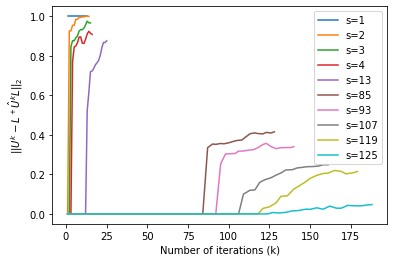

[graph] COMPLETED                                                               


In [32]:
generate_error_graph(WS, threshold=threshold)

[forward @ 1 COMPLETED (0.0314 sec)                                             
[forward @ 2 COMPLETED (0.0280 sec)                                             
[forward @ 3 COMPLETED (0.0309 sec)                                             
[forward @ 4 COMPLETED (0.0361 sec)                                             
[forward @ 13 COMPLETED (0.0758 sec)                                            
[forward @ 85 COMPLETED (0.5653 sec)                                            
[forward @ 93 COMPLETED (0.6384 sec)                                            
[forward @ 107 COMPLETED (0.7598 sec)                                           
[forward @ 119 COMPLETED (0.8415 sec)                                           
[forward @ 125 COMPLETED (0.7199 sec)                                           


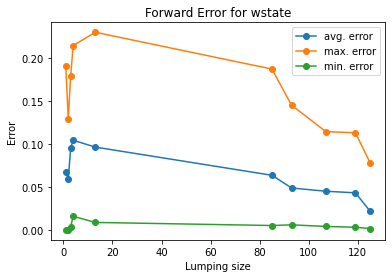

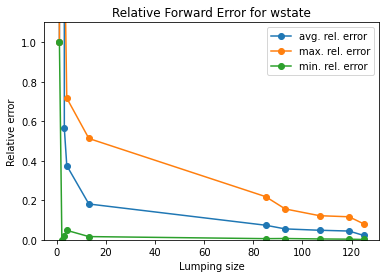

In [33]:
generate_error_graph(WS, method=forward_error, threshold=threshold)

## **Systematic analysis**

From the original Quantum CLUE paper, we collect the benchmark cases where we did not produce a lumping further than 50% in its last appearance (including those that were excluded due to having no exact reduction):

In [2]:
cases = [("qwalk", 7), ("ae", 7), ("portfolioqaoa", 7), ("portfoliovqe", 7), ("qpeexact", 7), ("qpeinexact", 7),
         ("qnn", 7), 
         #("tsp", 4), --> Restarts the kernel
         ("vqe", 7), ("wstate", 7)]

For each of these, we are going to do as following:

* Perform an approximate lumping analysis. It will look with threshold $\varepsilon_0 = 10^{-3}$ for all possible approximate lumpings using a binary search over the interval $[\varepsilon_0,\varepsilon_{max}]$.
* Compute the backward error. If $\ket{x} \in \langle L\rangle$, then $L^+ \hat{U}^k L \ket{x} = U^k \ket{x}$, so we measure for $\ket{0}$ how much this identity does not hold for $k$ varying from $1$ to $\max(3d/2, d + \sqrt{N})$, where $d$ is the size of an obtained approximate lumping and $N = 2^n$ is the original size space.
  We then show (and save) the graph showing this error when the iterations increase for each approximate lumping obtained in the binary search.
* Compute the forward error. In general, if $L$ is a lumping, then $LU\ket{x} = \hat{U}L\ket{x}$. We measure how much this identity does not hold for different lumpings $L$ by taking 100 random samples and measuring the error (distance) of the true value ($LU\ket{x}$) with the approximate value ($\hat{U}L\ket{x}$). We also compute the minimal and maximal errors on these samples. We also compute the relative error (relative to $||LU\ket{x}||_2$). We create two images for these cases: one with the absolute error and one with the relative error.

################################################################################
################################################################################
### Circuit: qwalk with 7 qubits.
################################################################################
[analysis] COMPLETED: Saved in file (32.9178 s., 66 lumpings, 9 dist. lumpings) 
Intervals:
64 -> (0.0, 0.28503759765625)
60 -> (0.28503759765625, 0.4275205078124998)
48 -> (0.4275205078124998, 0.43925732421875)
40 -> (0.43925732421875, 0.5661230468749998)
36 -> (0.5661230468749998, 0.7008452148437503)
32 -> (0.7008452148437503, 0.9546005859374997)
30 -> (0.9546005859374997, 0.9682895507812501)
2 -> (0.9682895507812501, 0.9994999999999996)
1 -> (0.9994999999999996, 1.0005000000000002)
[backward @ 1] COMPLETED (1.1008 sec, 13 iters.)                                
[backward @ 2] COMPLETED (0.6037 sec, 14 iters.)                                
[backward @ 30] COMPLETED (3.9634 sec, 45 iters.)                      

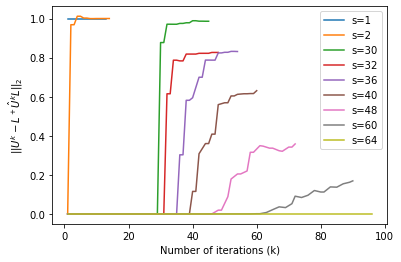

[graph] COMPLETED                                                               
[forward @ 1 COMPLETED (0.0601 sec)                                             
[forward @ 2 COMPLETED (0.0373 sec)                                             
[forward @ 30 COMPLETED (0.3230 sec)                                            
[forward @ 32 COMPLETED (0.3515 sec)                                            
[forward @ 36 COMPLETED (0.3962 sec)                                            
[forward @ 40 COMPLETED (0.4289 sec)                                            
[forward @ 48 COMPLETED (0.5382 sec)                                            
[forward @ 60 COMPLETED (0.6431 sec)                                            
[forward @ 64 COMPLETED (0.7292 sec)                                            


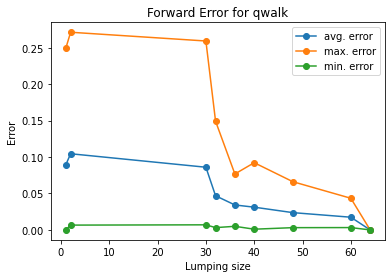

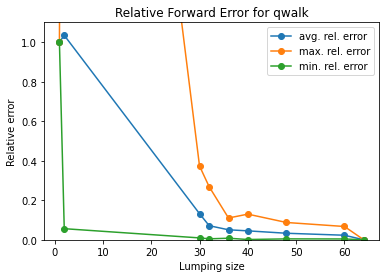

--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
################################################################################
################################################################################
### Circuit: ae with 7 qubits.
################################################################################


2024-09-03 13:52:35 WARNING  [lumping] lumped size (128) and original size (128) are the same.


2024-09-03 13:52:37 WARNING  [lumping] lumped size (128) and original size (128) are the same.


2024-09-03 13:57:19 WARNING  [lumping] lumped size (128) and original size (128) are the same.


2024-09-03 13:57:21 WARNING  [lumping] lumped size (128) and original size (128) are the same.


2024-09-03 13:57:37 WARNING  [lumping] lumped size (128) and original size (128) are the same.


2024-09-03 13:57:39 WARNING  [lumping] lumped size (128) and original size (128) are the same.


2024-09-03 13:57:41 WARNING  [lumping] lumped size (128) and original size (128) are the same.


2024-09-03 13:57:51 WARNING  [lumping] lumped size (128) and original size (128) are the same.


[analysis] COMPLETED: Saved in file (381.2450 s., 117 lumpings, 21 dist. lumpings)
Intervals:
128 -> (0.0, 0.7018091627533352)
85 -> (0.7018091627533352, 0.7505880865700765)
79 -> (0.7505880865700765, 0.7623247171972163)
75 -> (0.7623247171972163, 0.7779176918027972)
66 -> (0.7779176918027972, 0.7877022077704567)
63 -> (0.7877022077704567, 0.8101275836842179)
62 -> (0.8101275836842179, 0.8208881569816175)
55 -> (0.8208881569816175, 0.8364811315871985)
53 -> (0.8364811315871985, 0.846265647554858)
46 -> (0.846265647554858, 0.8638107368199188)
44 -> (0.8638107368199188, 0.8716431381280987)
42 -> (0.8716431381280987, 0.8823558260849793)
32 -> (0.8823558260849793, 0.9155657179663994)
20 -> (0.9155657179663994, 0.9438474378586008)
17 -> (0.9438474378586008, 0.9536319538262603)
13 -> (0.9536319538262603, 0.9643446417831414)
11 -> (0.9643446417831414, 0.9702249284318407)
8 -> (0.9702249284318407, 0.9819136737184617)
7 -> (0.9819136737184617, 0.9838897310482009)
2 -> (0.9838897310482009, 0.999

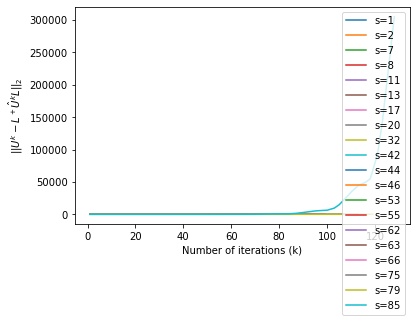

[graph] COMPLETED                                                               
[forward @ 1 COMPLETED (0.0435 sec)                                             
[forward @ 2 COMPLETED (0.0551 sec)                                             
[forward @ 7 COMPLETED (0.1565 sec)                                             
[forward @ 8 COMPLETED (0.1518 sec)                                             
[forward @ 11 COMPLETED (0.2147 sec)                                            
[forward @ 13 COMPLETED (0.2357 sec)                                            
[forward @ 17 COMPLETED (0.2358 sec)                                            
[forward @ 20 COMPLETED (0.2765 sec)                                            
[forward @ 32 COMPLETED (0.4421 sec)                                            
[forward @ 42 COMPLETED (0.7455 sec)                                            
[forward @ 44 COMPLETED (0.7810 sec)                                            
[forward @ 46 COMPLETED (0.8

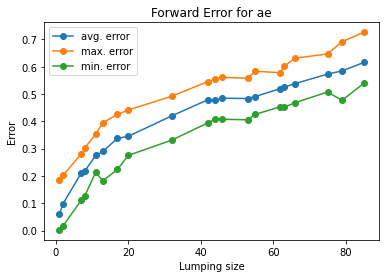

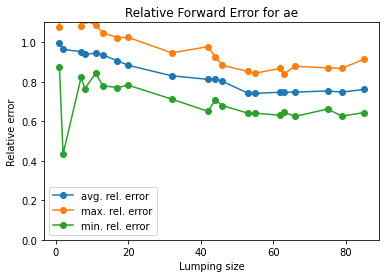

--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
################################################################################
################################################################################
### Circuit: portfolioqaoa with 7 qubits.
################################################################################


2024-09-03 14:02:18 WARNING  [lumping] lumped size (128) and original size (128) are the same.


2024-09-03 14:02:21 WARNING  [lumping] lumped size (128) and original size (128) are the same.


2024-09-03 14:02:31 WARNING  [lumping] lumped size (128) and original size (128) are the same.


2024-09-03 14:02:45 WARNING  [lumping] lumped size (128) and original size (128) are the same.


[analysis] COMPLETED: Saved in file (34.9381 s., 49 lumpings, 7 dist. lumpings) 
Intervals:
128 -> (0.0, 0.6248138762296909)
7 -> (0.6248138762296909, 0.6744987536733533)
6 -> (0.6744987536733533, 0.7339813045698866)
5 -> (0.7339813045698866, 0.8928336103537453)
4 -> (0.8928336103537453, 0.9532908704318872)
2 -> (0.9532908704318872, 0.9981022019675054)
1 -> (0.9981022019675054, 0.9991022019675053)
[backward @ 1] COMPLETED (3.7546 sec, 13 iters.)                                
[backward @ 2] COMPLETED (2.1059 sec, 14 iters.)                                
[backward @ 4] COMPLETED (2.9656 sec, 16 iters.)                                
[backward @ 5] COMPLETED (2.6527 sec, 17 iters.)                                
[backward @ 6] COMPLETED (2.7748 sec, 18 iters.)                                
[backward @ 7] COMPLETED (2.7264 sec, 19 iters.)                                


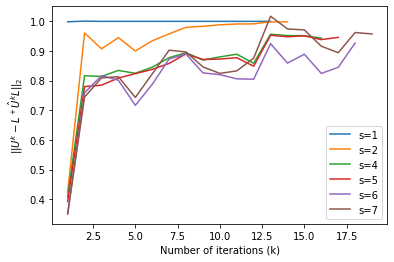

[graph] COMPLETED                                                               
[forward @ 1 COMPLETED (0.0937 sec)                                             
[forward @ 2 COMPLETED (0.0438 sec)                                             
[forward @ 4 COMPLETED (0.0719 sec)                                             
[forward @ 5 COMPLETED (0.0856 sec)                                             
[forward @ 6 COMPLETED (0.0984 sec)                                             
[forward @ 7 COMPLETED (0.1057 sec)                                             


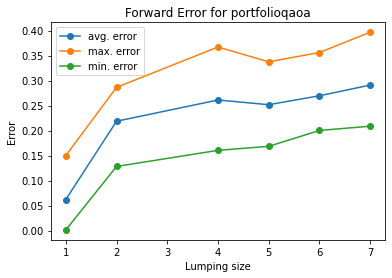

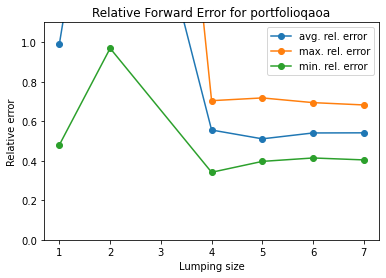

--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
################################################################################
################################################################################
### Circuit: portfoliovqe with 7 qubits.
################################################################################


2024-09-03 14:03:08 WARNING  [lumping] lumped size (128) and original size (128) are the same.


2024-09-03 14:10:05 WARNING  [lumping] lumped size (128) and original size (128) are the same.


2024-09-03 14:10:21 WARNING  [lumping] lumped size (128) and original size (128) are the same.


2024-09-03 14:10:23 WARNING  [lumping] lumped size (128) and original size (128) are the same.


2024-09-03 14:10:25 WARNING  [lumping] lumped size (128) and original size (128) are the same.


2024-09-03 14:10:41 WARNING  [lumping] lumped size (128) and original size (128) are the same.


[analysis] COMPLETED: Saved in file (511.0220 s., 70 lumpings, 9 dist. lumpings)
Intervals:
128 -> (0.0, 0.04582099158409853)
126 -> (0.04582099158409853, 0.07600081181651488)
124 -> (0.07600081181651488, 0.42192757313762097)
104 -> (0.42192757313762097, 0.6148270802079604)
90 -> (0.6148270802079604, 0.8087522178960366)
70 -> (0.8087522178960366, 0.8964198316819706)
18 -> (0.8964198316819706, 0.9383433457370173)
2 -> (0.9383433457370173, 0.9977542474373239)
1 -> (0.9977542474373239, 0.998754247437324)
[backward @ 1] COMPLETED (3.5500 sec, 13 iters.)                                
[backward @ 2] COMPLETED (2.3455 sec, 14 iters.)                                
[backward @ 18] COMPLETED (7.0813 sec, 30 iters.)                               
[backward @ 70] COMPLETED (24.2950 sec, 105 iters.)                             
[backward @ 90] COMPLETED (28.6827 sec, 135 iters.)                             
[backward @ 104] COMPLETED (35.5384 sec, 156 iters.)                            
[backwa

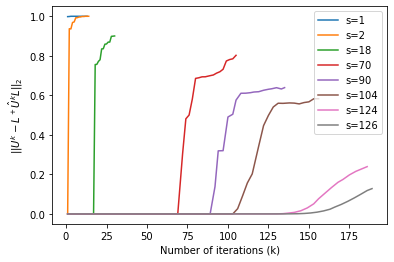

[graph] COMPLETED                                                               
[forward @ 1 COMPLETED (0.0515 sec)                                             
[forward @ 2 COMPLETED (0.0539 sec)                                             
[forward @ 18 COMPLETED (0.3339 sec)                                            
[forward @ 70 COMPLETED (1.3112 sec)                                            
[forward @ 90 COMPLETED (1.6655 sec)                                            
[forward @ 104 COMPLETED (1.9548 sec)                                           
[forward @ 124 COMPLETED (2.3860 sec)                                           
[forward @ 126 COMPLETED (2.4290 sec)                                           


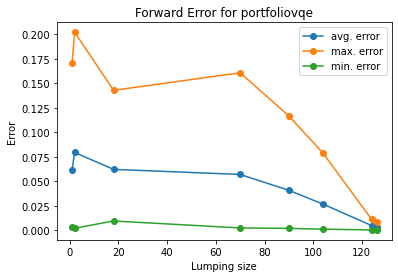

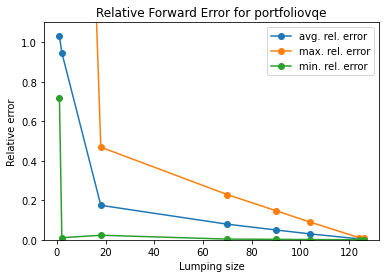

--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
################################################################################
################################################################################
### Circuit: qpeexact with 7 qubits.
################################################################################


2024-09-03 14:15:09 WARNING  [lumping] lumped size (128) and original size (128) are the same.


2024-09-03 14:15:10 WARNING  [lumping] lumped size (128) and original size (128) are the same.


2024-09-03 14:17:12 WARNING  [lumping] lumped size (128) and original size (128) are the same.


2024-09-03 14:17:38 WARNING  [lumping] lumped size (128) and original size (128) are the same.


2024-09-03 14:17:38 WARNING  [lumping] lumped size (128) and original size (128) are the same.


2024-09-03 14:17:39 WARNING  [lumping] lumped size (128) and original size (128) are the same.


2024-09-03 14:17:43 WARNING  [lumping] lumped size (128) and original size (128) are the same.


[analysis] COMPLETED: Saved in file (184.9827 s., 115 lumpings, 20 dist. lumpings)
Intervals:
128 -> (0.0, 0.5768837890624998)
127 -> (0.5768837890624998, 0.6119985351562502)
123 -> (0.6119985351562502, 0.6520415039062497)
97 -> (0.6520415039062497, 0.6861801757812502)
94 -> (0.6861801757812502, 0.6930366210937495)
86 -> (0.6930366210937495, 0.7525532226562504)
85 -> (0.7525532226562504, 0.7574575195312494)
78 -> (0.7574575195312494, 0.7652421875000004)
75 -> (0.7652421875000004, 0.7691704101562495)
63 -> (0.7691704101562495, 0.8033090820312503)
54 -> (0.8033090820312503, 0.8667778320312496)
53 -> (0.8667778320312496, 0.8696821289062502)
52 -> (0.8696821289062502, 0.8706821289062494)
51 -> (0.8706821289062494, 0.8755385742187503)
48 -> (0.8755385742187503, 0.8892275390624993)
38 -> (0.8892275390624993, 0.8950600585937505)
24 -> (0.8950600585937505, 0.9233901367187494)
10 -> (0.9233901367187494, 0.9692416992187505)
4 -> (0.9692416992187505, 0.9995239257812492)
1 -> (0.9995239257812492, 

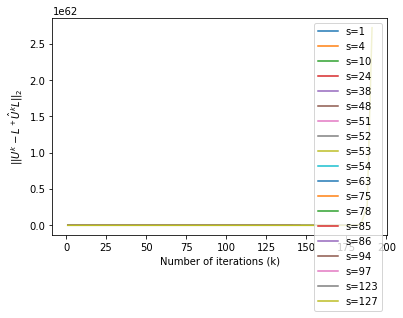

[graph] COMPLETED                                                               
[forward @ 1 COMPLETED (0.0227 sec)                                             
[forward @ 4 COMPLETED (0.0574 sec)                                             
[forward @ 10 COMPLETED (0.1151 sec)                                            
[forward @ 24 COMPLETED (0.3332 sec)                                            
[forward @ 38 COMPLETED (0.5103 sec)                                            
[forward @ 48 COMPLETED (0.6344 sec)                                            
[forward @ 51 COMPLETED (0.6703 sec)                                            
[forward @ 52 COMPLETED (0.7005 sec)                                            
[forward @ 53 COMPLETED (0.7050 sec)                                            
[forward @ 54 COMPLETED (0.7128 sec)                                            
[forward @ 63 COMPLETED (0.8434 sec)                                            
[forward @ 75 COMPLETED (0.8

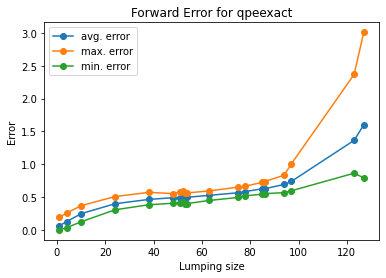

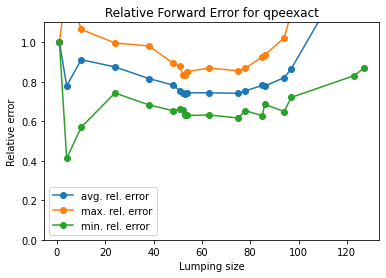

--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
################################################################################
################################################################################
### Circuit: qpeinexact with 7 qubits.
################################################################################


2024-09-03 14:20:29 WARNING  [lumping] lumped size (128) and original size (128) are the same.


2024-09-03 14:23:01 WARNING  [lumping] lumped size (128) and original size (128) are the same.


2024-09-03 14:23:02 WARNING  [lumping] lumped size (128) and original size (128) are the same.


2024-09-03 14:23:02 WARNING  [lumping] lumped size (128) and original size (128) are the same.


2024-09-03 14:23:10 WARNING  [lumping] lumped size (128) and original size (128) are the same.


2024-09-03 14:23:11 WARNING  [lumping] lumped size (128) and original size (128) are the same.


2024-09-03 14:23:19 WARNING  [lumping] lumped size (128) and original size (128) are the same.


[analysis] COMPLETED: Saved in file (204.3484 s., 143 lumpings, 25 dist. lumpings)
Intervals:
128 -> (0.0, 0.44999414062499987)
123 -> (0.44999414062499987, 0.5670991210937497)
119 -> (0.5670991210937497, 0.6061660156249997)
101 -> (0.6061660156249997, 0.7135102539062499)
95 -> (0.7135102539062499, 0.7184145507812496)
85 -> (0.7184145507812496, 0.7398642578125001)
73 -> (0.7398642578125001, 0.7447685546874996)
68 -> (0.7447685546874996, 0.7847636718750002)
64 -> (0.7847636718750002, 0.7896679687499997)
57 -> (0.7896679687499997, 0.8316152343749998)
55 -> (0.8316152343749998, 0.8374956054687497)
46 -> (0.8374956054687497, 0.847232421875)
42 -> (0.847232421875, 0.8706821289062494)
40 -> (0.8706821289062494, 0.8843232421875002)
38 -> (0.8843232421875002, 0.8872753906249993)
37 -> (0.8872753906249993, 0.8921318359375003)
36 -> (0.8921318359375003, 0.9038686523437491)
34 -> (0.9038686523437491, 0.9067729492187504)
31 -> (0.9067729492187504, 0.924366210937499)
26 -> (0.924366210937499, 0.936

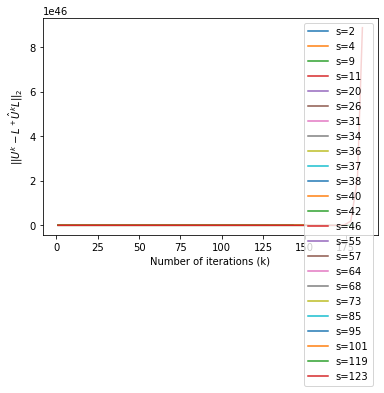

[graph] COMPLETED                                                               
[forward @ 2 COMPLETED (0.0462 sec)                                             
[forward @ 4 COMPLETED (0.0698 sec)                                             
[forward @ 9 COMPLETED (0.1428 sec)                                             
[forward @ 11 COMPLETED (0.1616 sec)                                            
[forward @ 20 COMPLETED (0.2688 sec)                                            
[forward @ 26 COMPLETED (0.3477 sec)                                            
[forward @ 31 COMPLETED (0.4139 sec)                                            
[forward @ 34 COMPLETED (0.3917 sec)                                            
[forward @ 36 COMPLETED (0.3798 sec)                                            
[forward @ 37 COMPLETED (0.4004 sec)                                            
[forward @ 38 COMPLETED (0.5055 sec)                                            
[forward @ 40 COMPLETED (0.5

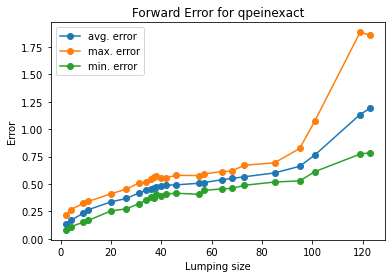

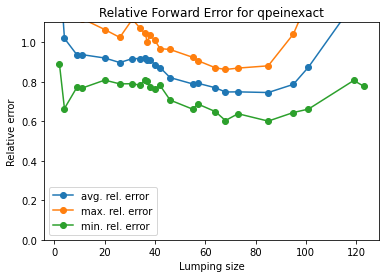

--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
################################################################################
################################################################################
### Circuit: qnn with 7 qubits.
################################################################################


2024-09-03 14:26:11 WARNING  [lumping] lumped size (128) and original size (128) are the same.


2024-09-03 14:26:13 WARNING  [lumping] lumped size (128) and original size (128) are the same.


2024-09-03 14:31:16 WARNING  [lumping] lumped size (128) and original size (128) are the same.


2024-09-03 14:32:16 WARNING  [lumping] lumped size (128) and original size (128) are the same.


...

2024-09-03 14:32:20 WARNING  [lumping] lumped size (128) and original size (128) are the same.


2024-09-03 14:32:32 WARNING  [lumping] lumped size (128) and original size (128) are the same.


2024-09-03 14:32:34 WARNING  [lumping] lumped size (128) and original size (128) are the same.


2024-09-03 14:32:37 WARNING  [lumping] lumped size (128) and original size (128) are the same.


[analysis] COMPLETED: Saved in file (479.4067 s., 110 lumpings, 20 dist. lumpings)
Intervals:
128 -> (0.0, 0.6785321603770693)
93 -> (0.6785321603770693, 0.7104879450019912)
78 -> (0.7104879450019912, 0.7686759242040613)
75 -> (0.7686759242040613, 0.7705837875533192)
74 -> (0.7705837875533192, 0.7764302264687488)
73 -> (0.7764302264687488, 0.7793073776010926)
68 -> (0.7793073776010926, 0.7967852699135536)
67 -> (0.7967852699135536, 0.7986931332628111)
66 -> (0.7986931332628111, 0.8268331911892177)
55 -> (0.8268331911892177, 0.8529732491156237)
54 -> (0.8529732491156237, 0.8636661269464834)
47 -> (0.8636661269464834, 0.8733282925604282)
46 -> (0.8733282925604282, 0.8830518826082021)
41 -> (0.8830518826082021, 0.8849597459574596)
38 -> (0.8849597459574596, 0.9160076672331239)
30 -> (0.9160076672331239, 0.9295469839794128)
29 -> (0.9295469839794128, 0.9324855595455848)
20 -> (0.9324855595455848, 0.9586256174719909)
4 -> (0.9586256174719909, 0.9925814020969126)
1 -> (0.9925814020969126, 0.

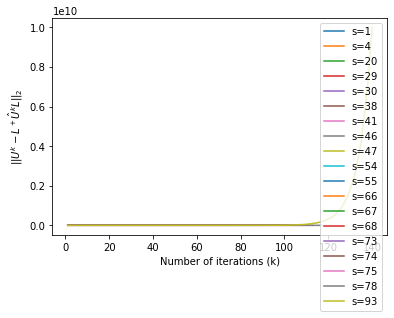

[graph] COMPLETED                                                               
[forward @ 1 COMPLETED (0.0319 sec)                                             
[forward @ 4 COMPLETED (0.0664 sec)                                             
[forward @ 20 COMPLETED (0.2792 sec)                                            
[forward @ 29 COMPLETED (0.4489 sec)                                            
[forward @ 30 COMPLETED (0.5212 sec)                                            
[forward @ 38 COMPLETED (0.6599 sec)                                            
[forward @ 41 COMPLETED (0.6921 sec)                                            
[forward @ 46 COMPLETED (0.6209 sec)                                            
[forward @ 47 COMPLETED (0.7519 sec)                                            
[forward @ 54 COMPLETED (0.9415 sec)                                            
[forward @ 55 COMPLETED (0.8919 sec)                                            
[forward @ 66 COMPLETED (0.9

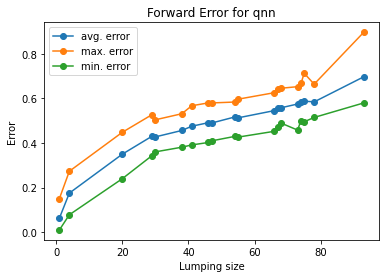

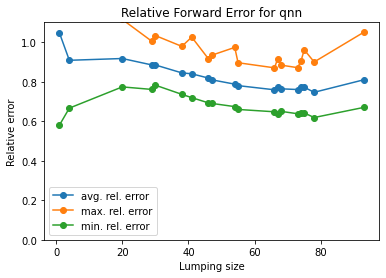

--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
################################################################################
################################################################################
### Circuit: vqe with 7 qubits.
################################################################################


2024-09-03 14:38:09 WARNING  [lumping] lumped size (128) and original size (128) are the same.


2024-09-03 14:45:46 WARNING  [lumping] lumped size (128) and original size (128) are the same.


2024-09-03 14:45:48 WARNING  [lumping] lumped size (128) and original size (128) are the same.


2024-09-03 14:46:04 WARNING  [lumping] lumped size (128) and original size (128) are the same.


2024-09-03 14:46:07 WARNING  [lumping] lumped size (128) and original size (128) are the same.


2024-09-03 14:46:36 WARNING  [lumping] lumped size (128) and original size (128) are the same.


[analysis] COMPLETED: Saved in file (583.8898 s., 70 lumpings, 11 dist. lumpings)
Intervals:
128 -> (0.0, 0.10641601562499994)
126 -> (0.10641601562499994, 0.6022377929687498)
125 -> (0.6022377929687498, 0.7115820312499997)
124 -> (0.7115820312499997, 0.8901796874999995)
116 -> (0.8901796874999995, 0.9477919921874997)
101 -> (0.9477919921874997, 0.9506962890624996)
74 -> (0.9506962890624996, 0.9604809570312497)
14 -> (0.9604809570312497, 0.9711938476562497)
6 -> (0.9711938476562497, 0.9760981445312494)
4 -> (0.9760981445312494, 0.9994999999999997)
1 -> (0.9994999999999997, 1.0004999999999993)
[backward @ 1] COMPLETED (3.8632 sec, 13 iters.)                                
[backward @ 4] COMPLETED (2.8042 sec, 16 iters.)                                
[backward @ 6] COMPLETED (2.6953 sec, 18 iters.)                                
[backward @ 14] COMPLETED (5.2038 sec, 26 iters.)                               
[backward @ 74] COMPLETED (27.4608 sec, 111 iters.)                         

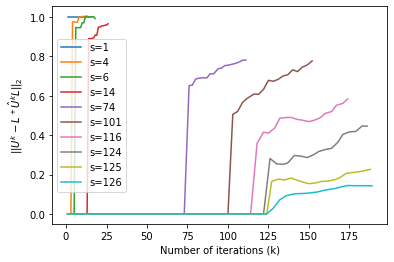

[graph] COMPLETED                                                               
[forward @ 1 COMPLETED (0.0703 sec)                                             
[forward @ 4 COMPLETED (0.0688 sec)                                             
[forward @ 6 COMPLETED (0.0932 sec)                                             
[forward @ 14 COMPLETED (0.1950 sec)                                            
[forward @ 74 COMPLETED (1.2365 sec)                                            
[forward @ 101 COMPLETED (1.9393 sec)                                           
[forward @ 116 COMPLETED (2.2165 sec)                                           
[forward @ 124 COMPLETED (2.1043 sec)                                           
[forward @ 125 COMPLETED (2.4074 sec)                                           
[forward @ 126 COMPLETED (2.4367 sec)                                           


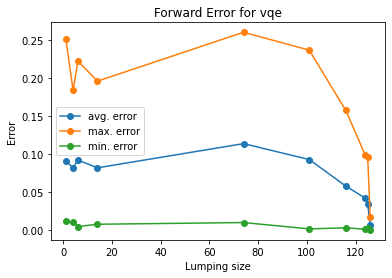

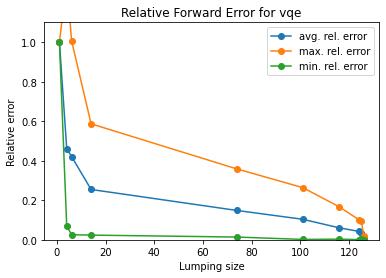

--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
################################################################################
################################################################################
### Circuit: wstate with 7 qubits.
################################################################################


2024-09-03 14:52:34 WARNING  [lumping] lumped size (128) and original size (128) are the same.


2024-09-03 14:56:44 WARNING  [lumping] lumped size (128) and original size (128) are the same.


2024-09-03 14:56:56 WARNING  [lumping] lumped size (128) and original size (128) are the same.


2024-09-03 14:56:58 WARNING  [lumping] lumped size (128) and original size (128) are the same.


2024-09-03 14:57:10 WARNING  [lumping] lumped size (128) and original size (128) are the same.


2024-09-03 14:57:31 WARNING  [lumping] lumped size (128) and original size (128) are the same.


2024-09-03 14:57:34 WARNING  [lumping] lumped size (128) and original size (128) are the same.


[analysis] COMPLETED: Saved in file (343.5270 s., 73 lumpings, 11 dist. lumpings)
Intervals:
128 -> (0.0, 0.35336279296875)
125 -> (0.35336279296875, 0.6198071289062499)
119 -> (0.6198071289062499, 0.781859375)
107 -> (0.781859375, 0.8159980468750001)
93 -> (0.8159980468750001, 0.8843471679687498)
85 -> (0.8843471679687498, 0.8960361328125004)
13 -> (0.8960361328125004, 0.9107011718749998)
4 -> (0.9107011718749998, 0.9126293945312505)
3 -> (0.9126293945312505, 0.9263183593749995)
2 -> (0.9263183593749995, 0.9995000000000005)
1 -> (0.9995000000000005, 1.0004999999999995)
[backward @ 1] COMPLETED (3.4981 sec, 13 iters.)                                
[backward @ 2] COMPLETED (1.4297 sec, 14 iters.)                                
[backward @ 3] COMPLETED (2.3181 sec, 15 iters.)                                
[backward @ 4] COMPLETED (2.4668 sec, 16 iters.)                                
[backward @ 13] COMPLETED (5.0681 sec, 25 iters.)                               
[backward @ 85] CO

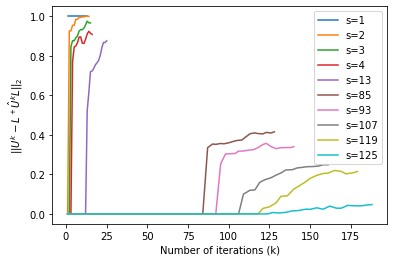

[graph] COMPLETED                                                               
[forward @ 1 COMPLETED (0.0488 sec)                                             
[forward @ 2 COMPLETED (0.0486 sec)                                             
[forward @ 3 COMPLETED (0.0638 sec)                                             
[forward @ 4 COMPLETED (0.0769 sec)                                             
[forward @ 13 COMPLETED (0.2214 sec)                                            
[forward @ 85 COMPLETED (1.4489 sec)                                            
[forward @ 93 COMPLETED (1.5475 sec)                                            
[forward @ 107 COMPLETED (1.4468 sec)                                           
[forward @ 119 COMPLETED (1.9992 sec)                                           
[forward @ 125 COMPLETED (2.2150 sec)                                           


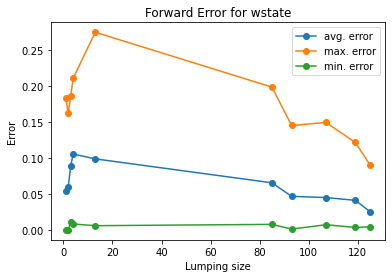

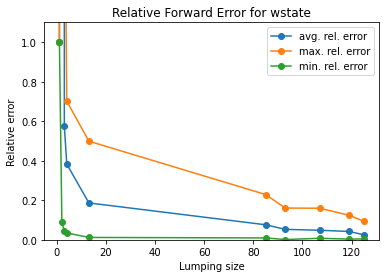

--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
CPU times: user 1h 10min 31s, sys: 14.7 s, total: 1h 10min 45s
Wall time: 1h 10min 24s


In [3]:
%%time
for case in cases:
    circuit = QuantumBenchmark.generate_example(case[0], case[1], 0)
    print("".ljust(get_terminal_size()[0], "#"), flush=True)
    print("".ljust(get_terminal_size()[0], "#"), flush=True)
    print("### Circuit:", circuit)
    print("".ljust(get_terminal_size()[0], "#"), flush=True)
    ## Computing the analysis
    A = analysis(circuit, threshold)
    print("Intervals:", flush=True)
    for (s, I) in epsilon_intervals(A, threshold).items():
        print(s, "->", I, flush=True)
    ## Computing the backward error
    generate_error_graph(circuit, threshold=threshold)
    ## Computing the forward error
    generate_error_graph(circuit, method=forward_error, threshold=threshold)
    print("".ljust(get_terminal_size()[0], "-"), flush=True)
    print("".ljust(get_terminal_size()[0], "-"), flush=True)